**BI_2 — ETL Process with Data Visualization**

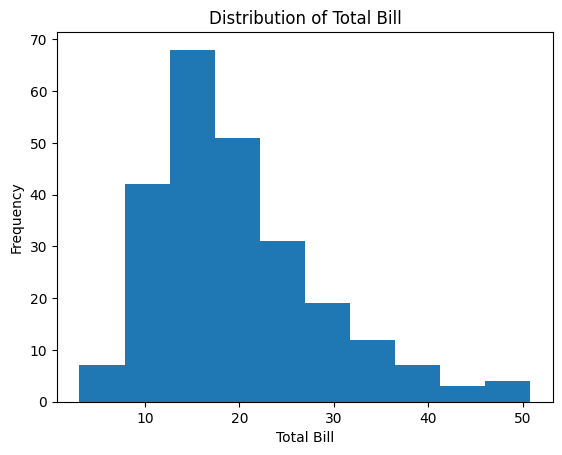

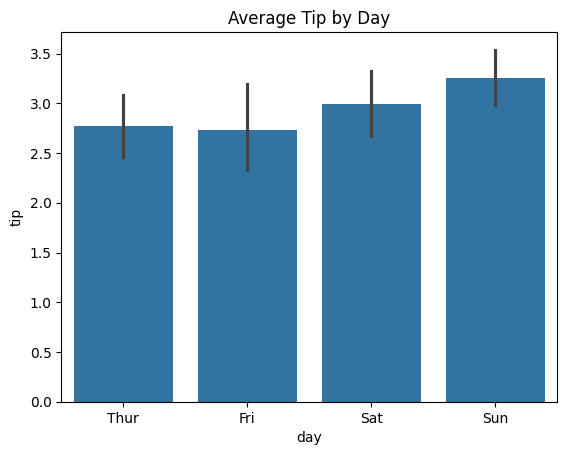

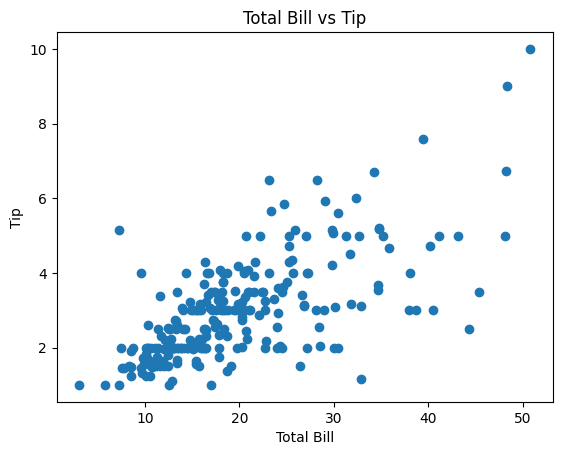

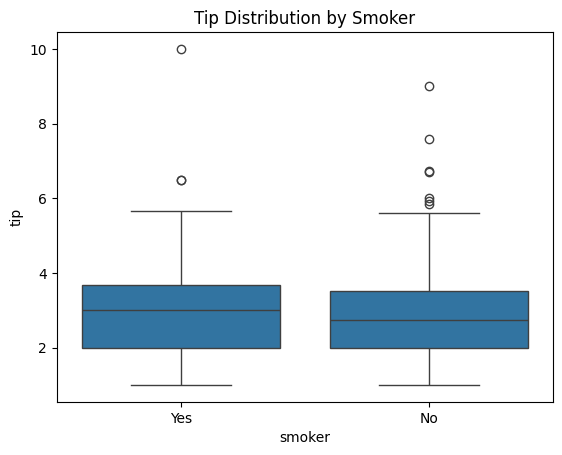

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Extract
df = sns.load_dataset('tips')

# Step 2: Check missing values
rows_before = len(df)

# Step 3: Transform
df_cleaned = df.dropna()
rows_after = len(df_cleaned)

# Step 4: Load
df_cleaned.to_csv("Cleaned_Tips_Data.csv", index=False)

# -------------------------------
# # Visualization 1: ETL Process
# # -------------------------------
# stages = ['Extracted', 'After Transform', 'Loaded']
# record_counts = [rows_before, rows_after, rows_after]

# plt.figure()
# plt.bar(stages, record_counts)
# plt.title('ETL Process Record Flow')
# plt.ylabel('Number of Records')

# for i, count in enumerate(record_counts):
#     plt.text(i, count, str(count), ha='center')

# plt.show()

# -------------------------------
# Visualization 2: Total Bill Distribution
# -------------------------------
plt.figure()
plt.hist(df_cleaned['total_bill'])
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

# -------------------------------
# Visualization 3: Tips by Day
# -------------------------------
plt.figure()
sns.barplot(x='day', y='tip', data=df_cleaned)
plt.title('Average Tip by Day')
plt.show()

# -------------------------------
# Visualization 4: Total Bill vs Tip
# -------------------------------
plt.figure()
plt.scatter(df_cleaned['total_bill'], df_cleaned['tip'])
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.show()

# -------------------------------
# Visualization 5: Boxplot (Smoker vs Tip)
# -------------------------------
plt.figure()
sns.boxplot(x='smoker', y='tip', data=df_cleaned)
plt.title('Tip Distribution by Smoker')
plt.show()

**BI 3 : data visualization and analysis using the excel**

Total Bill: 4827.77
Average Tip: 2.99827868852459

Pivot Table:
            tip
day           
Thur  2.771452
Fri   2.734737
Sat   2.993103
Sun   3.255132


/tmp/ipykernel_14878/601810202.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='tip', index='day', aggfunc='mean')


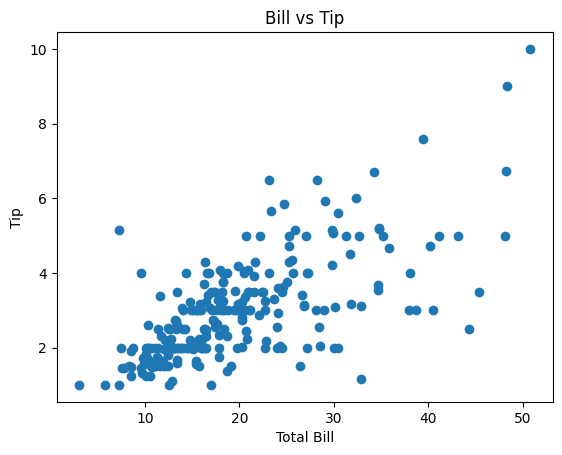

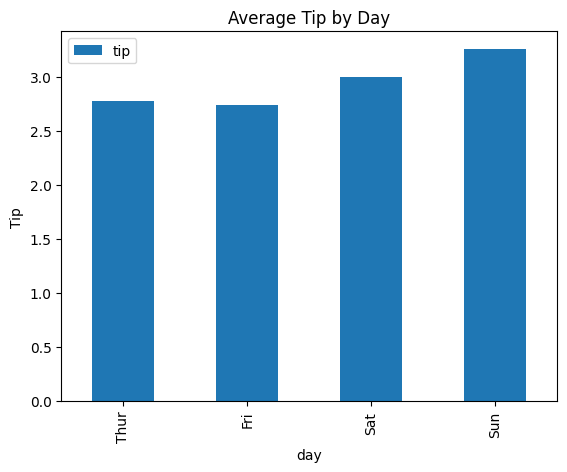

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset('tips')

# =========================
# Basic Analysis
# =========================
print("Total Bill:", df['total_bill'].sum())
print("Average Tip:", df['tip'].mean())

# =========================
# Pivot Table
# =========================
pivot = df.pivot_table(values='tip', index='day', aggfunc='mean')
print("\nPivot Table:\n", pivot)

# =========================
# Export to Excel
# =========================
df.to_excel('output.xlsx', index=False)
pivot.to_excel('pivot.xlsx')

# =========================
# Visualization
# =========================

# 1. Scatter Plot
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Bill vs Tip')
plt.show()

# 2. Bar Chart
pivot.plot(kind='bar')
plt.title('Average Tip by Day')
plt.ylabel('Tip')
plt.show()

**BI 4 - Classification
**

Accuracy: 79.02%


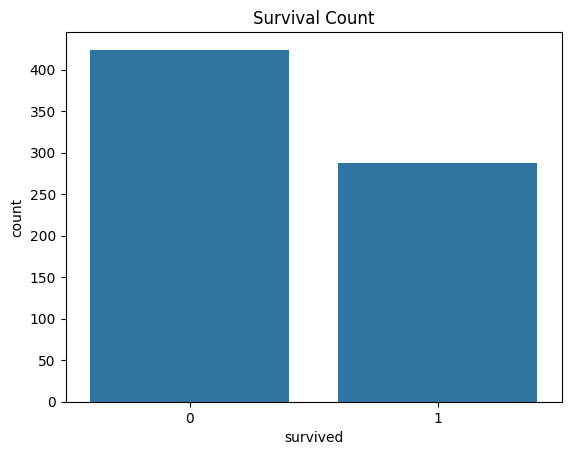

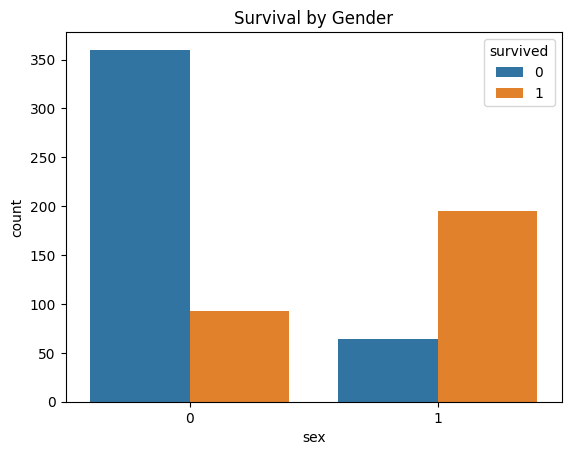

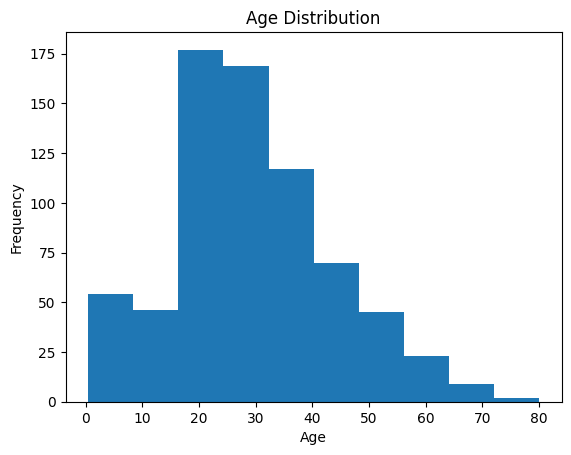

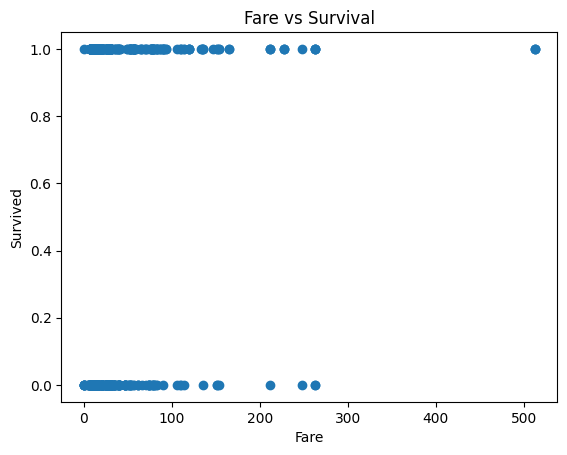

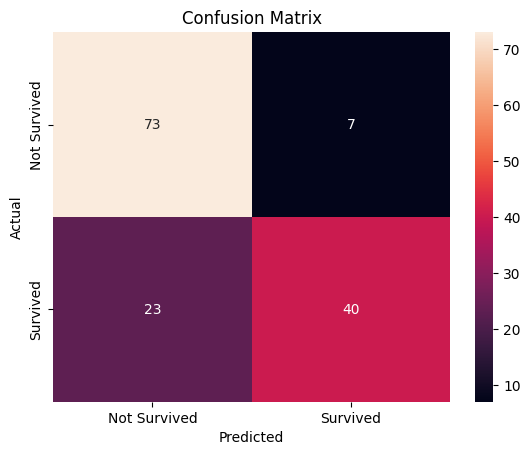

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = sns.load_dataset('titanic')

# -------------------------------
# Data Cleaning
# -------------------------------
df = df.dropna(subset=['age', 'sex', 'embarked', 'fare'])

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# -------------------------------
# Features & Target
# -------------------------------
X = df[['pclass', 'sex', 'age', 'fare', 'embarked']]
y = df['survived']

# -------------------------------
# Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Model Training
# -------------------------------
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# -------------------------------
# Accuracy Only
# -------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

# -------------------------------
# Visualization 1: Survival Count
# -------------------------------
plt.figure()
sns.countplot(x='survived', data=df)
plt.title('Survival Count')
plt.show()

# -------------------------------
# Visualization 2: Survival by Gender
# -------------------------------
plt.figure()
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival by Gender')
plt.show()

# -------------------------------
# Visualization 3: Age Distribution
# -------------------------------
plt.figure()
plt.hist(df['age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# -------------------------------
# Visualization 4: Fare vs Survival
# -------------------------------
plt.figure()
plt.scatter(df['fare'], df['survived'])
plt.title('Fare vs Survival')
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.show()

# -------------------------------
# Visualization 5: Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**BI 5 - Kmeans clustering **

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


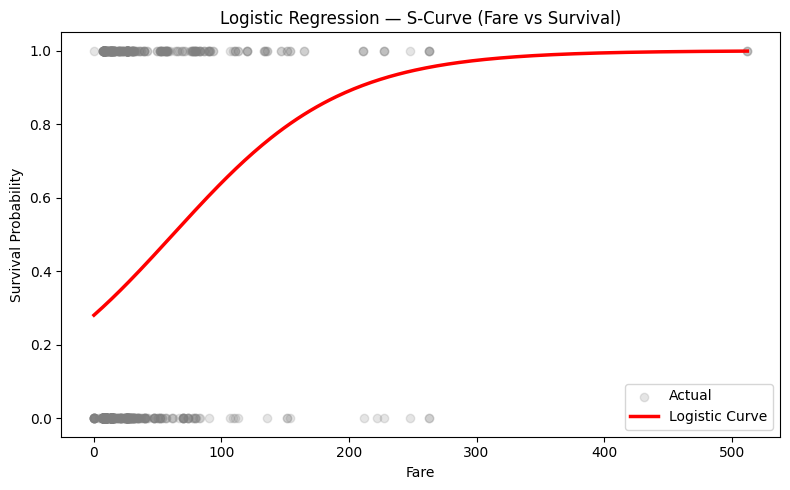

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

df = sns.load_dataset('titanic')
df = df.dropna(subset=['fare', 'survived'])

X = df[['fare']]
y = df['survived']

model = LogisticRegression()
model.fit(X, y)

fare_range = np.linspace(df['fare'].min(), df['fare'].max(), 300).reshape(-1, 1)
prob = model.predict_proba(fare_range)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(df['fare'], df['survived'], alpha=0.2, color='gray', label='Actual')
plt.plot(fare_range, prob, color='red', linewidth=2.5, label='Logistic Curve')
plt.xlabel("Fare")
plt.ylabel("Survival Probability")
plt.title("Logistic Regression — S-Curve (Fare vs Survival)")
plt.legend()
plt.tight_layout()
plt.show()

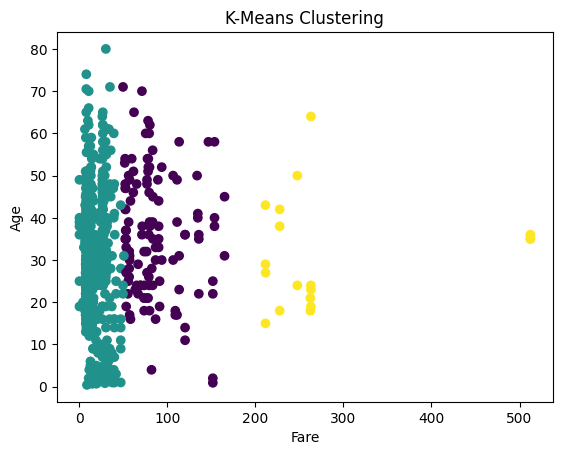

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load dataset
df = sns.load_dataset('titanic')

# Basic cleaning
df = df.dropna(subset=['fare', 'age'])

# Features
X = df[['fare', 'age']]

# Apply K-Means
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

# Plot
plt.scatter(df['fare'], df['age'], c=df['cluster'])
plt.xlabel("Fare")
plt.ylabel("Age")
plt.title("K-Means Clustering")
plt.show()

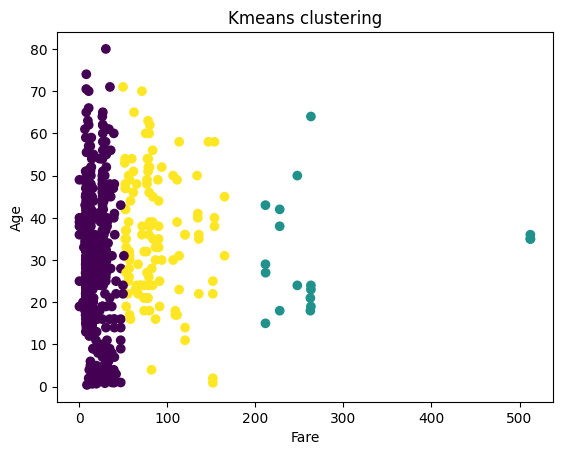

In [ ]:
import matplotlib as pyplot
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns

df = sns.load_dataset('titanic')

df = df.dropna(subset = ['fare','age'])

X = df[['fare','age']]

Kmeans = KMeans(n_clusters = 3)
df['cluster'] = Kmeans.fit_predict(X)

plt.scatter(df['fare'],df['age'],c = df['cluster'])
plt.xlabel('Fare')
plt.ylabel('Age')
plt.title("Kmeans clustering")
plt.show()
